# Debugging Notebook for functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from mesh import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

1
Number of '7' in this set: 47, number of '1' in this set: 63


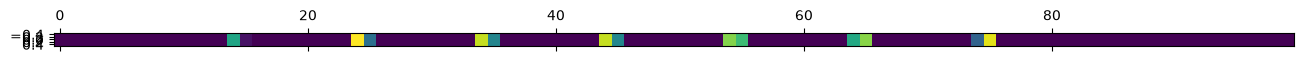

In [9]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 110 #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X, Y = get_data(values, mode, number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#Example of the first entry
plt.matshow(np.real(E_X[:,0]).reshape(1, -1)) #reshaping it just for plotting with plt.matshow
print(Y[0])

print("Number of '7' in this set: " + str(np.sum(Y == 7))+", number of '1' in this set: " + str(np.sum(Y == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

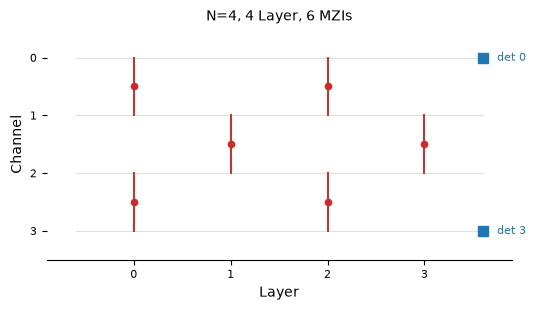

In [10]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)


plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)


# Initializing Mesh parameters
Functions in mesh.py, here just init_random, also init_haar already coded (later used)

Phis: [array([2.9756803 , 1.83079624]), array([2.52090954]), array([1.93396851, 2.03204352]), array([0.44527478])]
Thetas: [array([4.31061356, 5.62610221]), array([1.15876451]), array([5.83723495, 2.75939248]), array([3.50662814])]


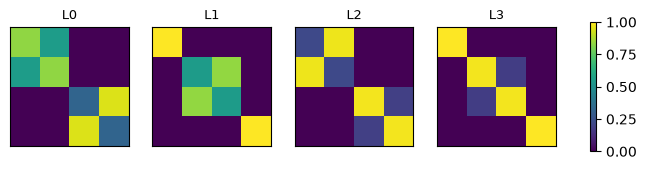

In [11]:
phis, thetas = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")

layers = test_mesh.layer_matrices(thetas, phis)   #building layers (transfer matrices) out of the parameters
fig, _ = plot_layers(layers, mode="Abs")


# Propagation

[[ 0.08139441+0.09045681j  0.06679912-0.00458662j  0.02218631-0.02491489j
  ...  0.07354939-0.01934643j -0.00426639+0.01429743j
   0.02737189-0.01578479j]
 [-0.03557436+0.06386237j  0.01504483-0.00324305j  0.04820454+0.01016424j
  ...  0.00507629-0.01346877j  0.03168841+0.02825878j
  -0.0141175 -0.0079613j ]
 [-0.00405537+0.092341j   -0.02261823+0.03369778j  0.03002307+0.02958465j
  ... -0.00959407+0.03903262j -0.02673472+0.01821474j
  -0.01299747+0.03785285j]
 ...
 [-0.02369296-0.01364463j -0.01954093-0.0687123j  -0.01672253-0.0257156j
  ... -0.08564135-0.09276466j -0.00919763-0.00719695j
  -0.04202885-0.0210739j ]
 [ 0.01105966-0.02220848j  0.02912427+0.07708892j  0.04299781+0.00806002j
  ... -0.11006854+0.1208815j   0.0001542 -0.00859887j
  -0.07701029+0.04793724j]
 [-0.00992347-0.00510357j -0.01075067-0.02105005j  0.03926464-0.04032633j
  ... -0.01202237+0.08042662j -0.00589802-0.00085171j
   0.00046806+0.05197209j]]
(100, 110)
[[[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.0

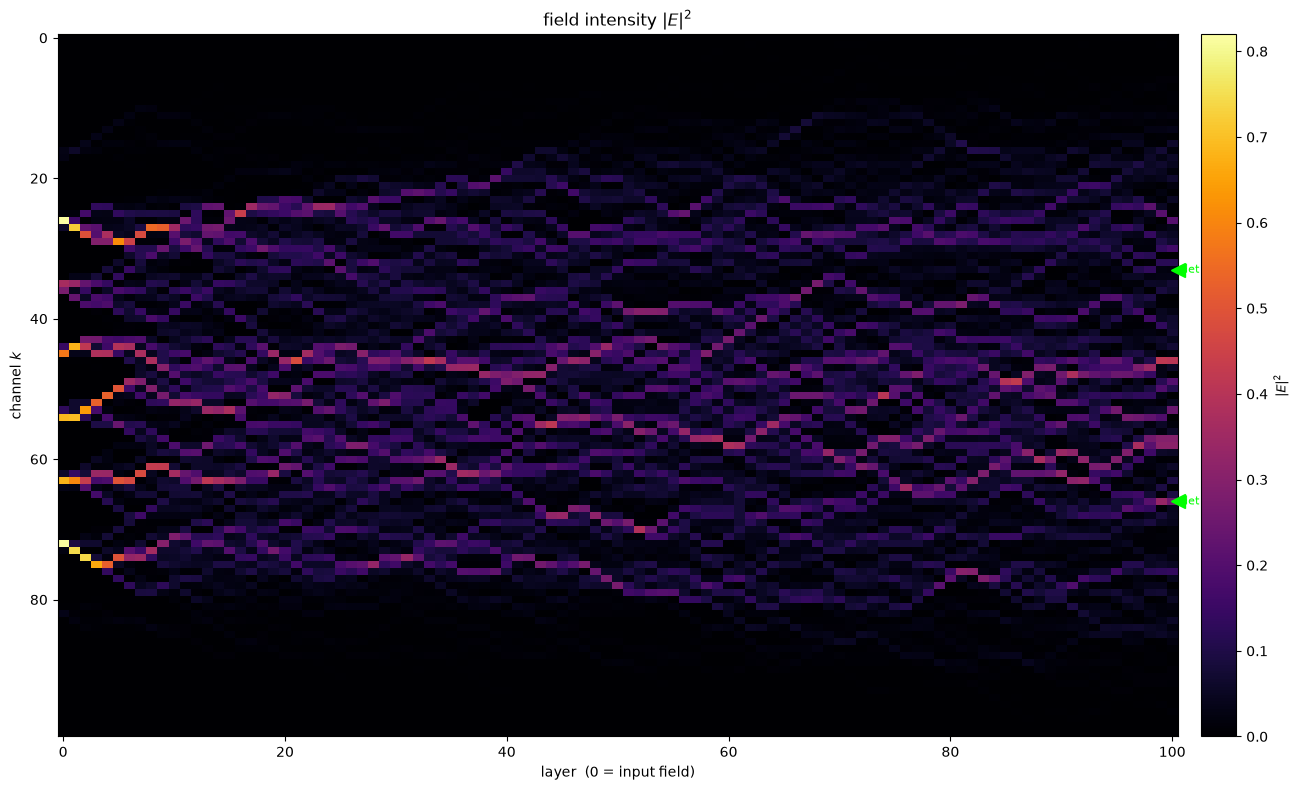

In [18]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters

E_out  = forward(E_X, layers)         #propagation that gives end result directly
print(E_out)                          #format: [channels, batches]
print(np.shape(E_out))

E_hist = forward_history(E_X, layers) #propagation that gives all E-fields for every layer
print(E_hist)                         #format: [layers, channels, batches]
I = np.abs(E_hist[:,:,2])**2
fig, _ = plot_intensity_map(I, detectors=[33,66])

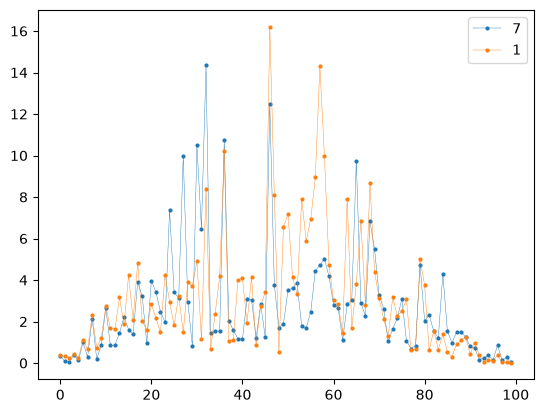

In [38]:
#Can plot intensity distribution over the channel number:
mask7 = Y==7
mask1 = Y==1
I7 = np.abs(E_hist[:,:,mask7])**2
I1 = np.abs(E_hist[:,:,mask1])**2
I_cumm7 = np.sum(I7, axis=2) 
I_cumm1 = np.sum(I1, axis=2) 
#plt.plot(I[-1,:], linewidth=0.3, marker="o", markersize=2)

plt.plot(I_cumm7[-1,:], linewidth=0.3, marker="o", markersize=2, label="7")
plt.plot(I_cumm1[-1,:], linewidth=0.3, marker="o", markersize=2, label="1")
plt.legend()